In [2]:
# Jupyter-specific commands to auto-reload external modules and display plots inline
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import pandas as pd
from typing import cast, Optional
import re
import json
import glob
import numpy as np


# Ensure project root directory, not the notebooks directory
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Add this new root directory to the path so imports work
sys.path.append(os.getcwd())
project_root = os.getcwd()

print(f"Working Directory set to: {os.getcwd()}")

# Preprocessing Imports
from utils.trajectory_processing.trajectories_to_pixel_space import trajectories_to_pixel_space

# Simulation Imports
from src.simulate_fits_data import simulate_fits_data

# Detection Pipeline Imports
from src.process_fits_files import process_fits_directory 

# Tracking Imports
from utils.config_loader import EKFTrackerConfig
from src.tomht_ekf import TOMHTTracker
from utils.post_process import (
    animate_tracks,
    print_tomht_stats,
    compute_mota,
    compute_mota,
    compute_motp,
    compute_ttft,
    plot_covariance_evolution_ric,
    plot_longest_tracks_cwh
)

Working Directory set to: d:\tanne\Documents\cso_tomht


In [3]:
# --- PIPELINE CONFIGURATION ---
CONFIG_FILE_PATH = "config/parameters.jsonx"
TARGET_TRAJECTORY_CSV_FOLDER = "data/project_data/case_1"
DETECTIONS_CSV_OUTPUT = "data/project_data/case_1/detections/master_detections_with_covariance.csv"
INPUT_FITS_DIR = "results/simulated_data/fits"
OUTPUT_CSV_DIR = "results/detections"
OUTPUT_PLOT_DIR = "results/detection_frames"

# Ensure the master results directory exists
os.makedirs("results", exist_ok=True)

In [ ]:
# --- HELPER FUNCTION ---
def load_json_with_comments(filepath):
    """Loads a JSON file that contains // or /* */ comments."""
    with open(filepath, 'r') as f:
        content = f.read()
    # Strip comments out before parsing
    content = re.sub(r'//.*?\n|/\*.*?\*/', '', content, flags=re.S)
    return json.loads(content)

def simulate_data(trajectory_folder: str, config: dict):
    """Step 1: Converts RIC trajectories to pixel space, then generates synthetic FITS."""
    print("\n" + "="*40)
    print(" STEP 1: SIMULATING IMAGE DATA")
    print("="*40)
    
    # 1. Gather all CSV files in the target folder
    csv_files = glob.glob(os.path.join(trajectory_folder, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {trajectory_folder}")
    
    # 2. Build the dictionary mapping IDs to filepaths dynamically
    trajectory_files = {}
    for filepath in csv_files:
        obj_id = os.path.splitext(os.path.basename(filepath))[0] 
        trajectory_files[obj_id] = filepath
        
    print(f"Found {len(trajectory_files)} object trajectories: {list(trajectory_files.keys())}")
    
    # 3. Convert kinematics to sensor pixel coordinates
    print("Converting CW frame dynamics to optical pixel coordinates...")
    # --> Pass the config dictionary into the conversion function
    pixel_trajectory_df = trajectories_to_pixel_space(trajectory_files, config)
    
    # 4. Save the combined pixel trajectories to a master CSV 
    os.makedirs("results", exist_ok=True)
    master_pixel_csv = os.path.join("results", "master_pixel_trajectories.csv")
    pixel_trajectory_df.to_csv(master_pixel_csv, index=False)
    print(f"Saved merged pixel trajectories to {master_pixel_csv}")

    # 5. Call your data simulation function
    # Note: If your simulate_fits_data function also needs the config dict now, 
    # you can pass it here as well!
    simulate_fits_data(master_pixel_csv, config=config, verbose=False)

# --- EXECUTION ---
# Load the configuration file (handling the // comments)
pipeline_config = load_json_with_comments(CONFIG_FILE_PATH)

# Execute Step 1 (Updated arguments to match the folder setup and pass the config)
simulate_data(trajectory_folder=TARGET_TRAJECTORY_CSV_FOLDER, config=pipeline_config)

In [ ]:
def detect_sources(input_dir: str, output_csv: str, output_plot: str):
    """Step 2: Runs background subtraction and matched filtering on the simulated FITS files."""
    print("\n" + "="*40)
    print(" STEP 2: SOURCE DETECTION (MATCHED FILTER)")
    print("="*40)
    
    process_fits_directory(
        input_dir=input_dir, 
        output_csv_dir=output_csv, 
        output_plot_dir=output_plot,
        sigma_psf=0.5, 
        threshold_factor=8.0,
        skip_bg_sub=False,
        verbose=True,
        generate_gif=False
    )

# Execute Step 2
detect_sources(
    input_dir=INPUT_FITS_DIR,
    output_csv=OUTPUT_CSV_DIR,
    output_plot=OUTPUT_PLOT_DIR
)


 STEP 3: TOMHT MULTI-TARGET TRACKING (CWH-EKF PINHOLE)
[*] Loaded 25 raw detections. Converting coordinates...

[DEBUG] Innovation (z - z_pred): [-7.77145684e-06  7.02050696e-06 -1.37041861e+06]
[DEBUG] S Matrix Diagonal: [4.19903584e+01 4.19903584e+01 4.19904013e+15]

[DEBUG] Innovation (z - z_pred): [-2.92694264e-05  2.55031915e-05 -5.38783699e+06]
[DEBUG] S Matrix Diagonal: [4.51737940e+02 4.05639016e+02 4.09432486e+16]

[DEBUG] Innovation (z - z_pred): [-7.94617000e-02  4.93296251e-06 -1.40200779e+06]
[DEBUG] S Matrix Diagonal: [5.18192874e+01 5.17987865e+01 4.19904014e+15]

[DEBUG] Innovation (z - z_pred): [-6.51563106e-05  5.65388234e-05 -1.17770946e+07]
[DEBUG] S Matrix Diagonal: [1.77396040e+03 1.32689323e+03 1.37914898e+17]

[DEBUG] Innovation (z - z_pred): [-2.82085602e-01  9.65762339e-06 -2.68040125e+06]
[DEBUG] S Matrix Diagonal: [1.83262983e+02 1.85483282e+02 1.12016465e+16]

[DEBUG] Innovation (z - z_pred): [-3.29541374e-01  2.96259933e-05 -5.91833345e+06]
[DEBUG] S Matr

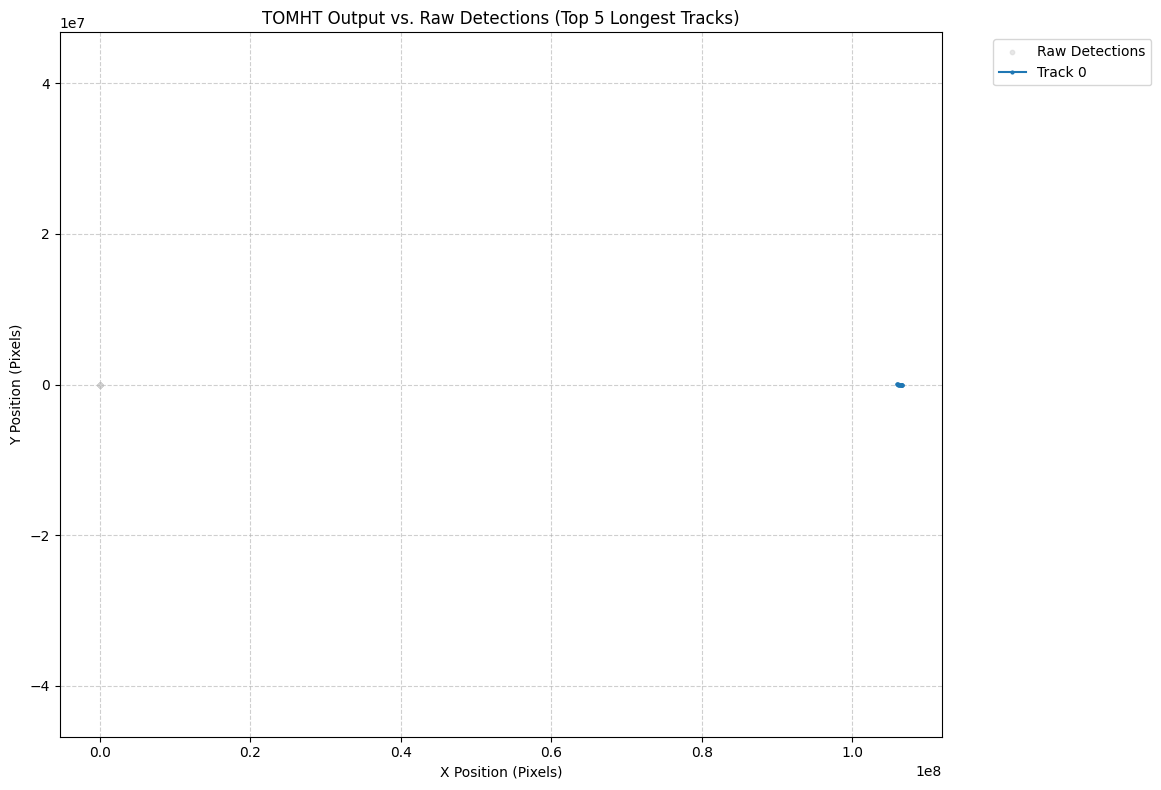

[*] Saved track plot to results/tomht_eval/tomht_longest_tracks.png
[✓] Tracker visualizations saved to: results/tomht_eval/


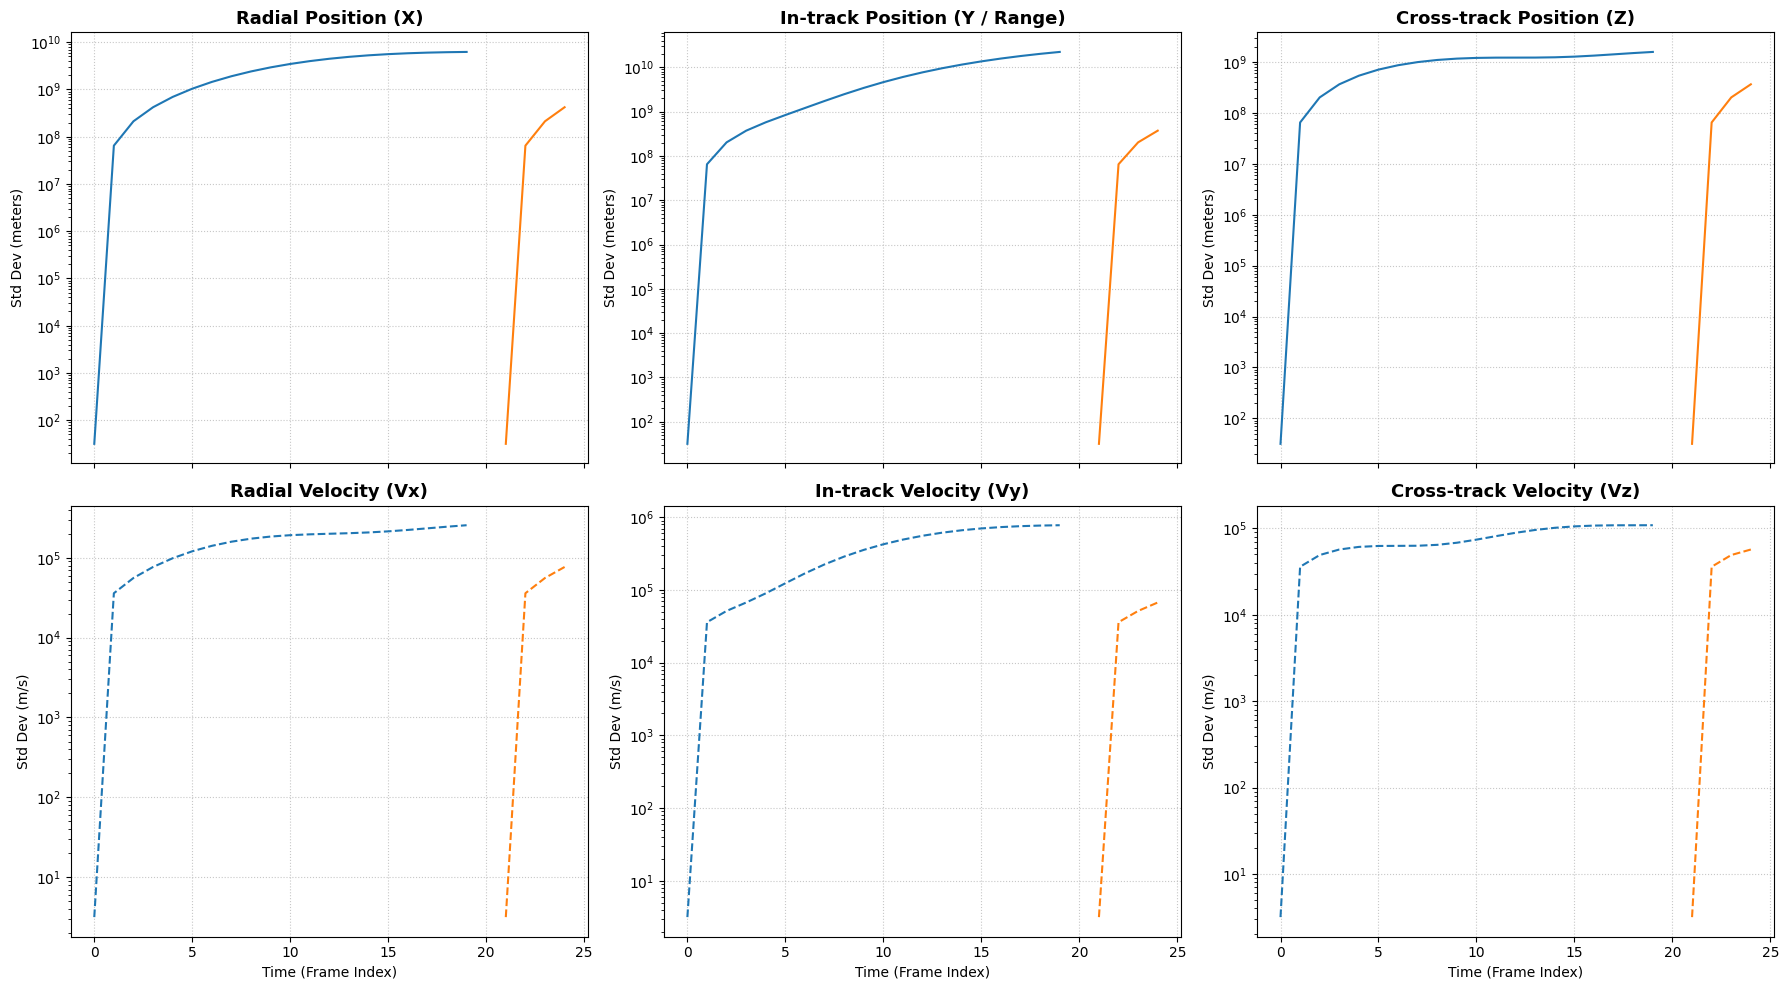

[*] RIC Covariance plot saved to results/tomht_eval/covariance_ric_plot.png

 END-TO-END TOMHT TRACKING COMPLETE


In [ ]:
def inject_cwh_pseudo_range(
    df: pd.DataFrame, 
    initial_state: np.ndarray, 
    mean_motion: float, 
    dt: float = 3600.0,
    noise_std: float = 0.01
) -> pd.DataFrame:
    """Propagates an initial 6D state using CWH dynamics to generate pseudo-range."""
    
    def get_cwh_stm(t: float, n: float) -> np.ndarray:
        """Computes the continuous CWH State Transition Matrix for elapsed time t."""
        nt = n * t
        s = np.sin(nt)
        c = np.cos(nt)
        
        return np.array([
            [4 - 3*c,       0.0,        0.0, s/n,          (2/n)*(1 - c), 0.0],
            [6*(s - nt),    1.0,        0.0, -(2/n)*(1-c), (4*s - 3*nt)/n, 0.0],
            [0.0,           0.0,        c,   0.0,          0.0,           s/n],
            [3*n*s,         0.0,        0.0, c,            2*s,           0.0],
            [-6*n*(1 - c),  0.0,        0.0, -2*s,         4*c - 3,       0.0],
            [0.0,           0.0,        -n*s,0.0,          0.0,           c]
        ])

    rho_values = []
    
    for _, row in df.iterrows():
        t_seconds = row['Frame_Idx'] * dt
        F_t = get_cwh_stm(t_seconds, mean_motion)
        state_t = F_t @ initial_state
        
        # ---> FIX: The target is in-track, so Y (index 1) is our depth <---
        rho_truth = abs(state_t[2])
        
        rho_measured = rho_truth + np.random.normal(0, noise_std)
        rho_values.append(rho_measured)
        
    df['rho'] = rho_values
    return df
    


def run_tracker(csv_path: str, generate_gif: bool = False, verbose: bool = True):
    """Step 3: Runs the TOMHT Tracker with Pinhole CWH-EKF dynamics."""
    print("\n" + "="*40)
    print(" STEP 3: TOMHT MULTI-TARGET TRACKING (CWH-EKF PINHOLE)")
    print("="*40)
    
    output_dir = "results/tomht_eval/"
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Load data
    raw_df = pd.read_csv(csv_path)
    if verbose: print(f"[*] Loaded {len(raw_df)} raw detections. Converting coordinates...")

    # --- SENSOR INTRINSICS ---
    image_width = 256
    image_height = 256
    cx = image_width / 2.0
    cy = image_height / 2.0
    pixel_pitch = 1.5e-6  
    
    config = EKFTrackerConfig.from_jsonx(CONFIG_FILE_PATH)
    mean_motion = config.mean_motion
    dt = config.dt

    # --- PIXEL TO FOCAL PLANE CONVERSION ---
    raw_df['u'] = (raw_df['Centroid_X'] - cx) * pixel_pitch
    raw_df['v'] = (raw_df['Centroid_Y'] - cy) * pixel_pitch
    
    # --- INJECT CWH PSEUDO-RANGE ---
    known_initial_state = np.array([
        -0.10380404290286323*1000,   
        -0.7725910003172296*1000,            
        0,               
        -2.816889913006161e-02,      
        1.5139675844188028e-02,     
        0.0                
    ])    

    raw_df = inject_cwh_pseudo_range(
        df=raw_df, 
        initial_state=known_initial_state, 
        mean_motion=mean_motion, 
        dt=dt,
        noise_std=config.range_noise_std 
    )

    rename_map = {'Frame_Idx': 'time'}
    raw_df = raw_df.rename(columns=rename_map)
    
    if not hasattr(config, "min_distance_px"):
        config.min_distance_px = 1.0  
        
    if not hasattr(config, "min_age_to_check"):
        config.min_age_to_check = 3   

    tracker = TOMHTTracker(config) 
    
    n_scan = config.n_scan_window 
    results = []
    cov_results = []
    
    # --- NEW: Diagnostic Lists ---
    diag_gating_list = []
    diag_updates_list = []
    
    # 3. Tracking Loop
    unique_times = sorted(raw_df['time'].unique())
    for i, (t_raw, group) in enumerate(raw_df.groupby('time')):
        t = cast(int, t_raw) 
        
        meas_t = group[['u', 'v', 'rho']].to_numpy()
        
        # --- CRITICAL CHANGE: Unpack the new diagnostics dictionary ---
        active_tracks, frame_diag = tracker.step(meas_t)

        # --- NEW: Store Diagnostics for this frame ---
        for gate_info in frame_diag["gating"]:
            gate_info["time"] = t
            diag_gating_list.append(gate_info)
            
        for upd_info in frame_diag["updates"]:
            upd_info["time"] = t
            diag_updates_list.append(upd_info)

        for track in active_tracks:
            curr_P = track.best_hypothesis.covariance
            curr_P = np.maximum(curr_P, 0.0) 
            
            cov_results.append({
                'time': t,
                'id': track.track_id,
                'std_x': np.sqrt(curr_P[0, 0]),
                'std_y': np.sqrt(curr_P[1, 1]),
                'std_z': np.sqrt(curr_P[2, 2]),
                'std_vx': np.sqrt(curr_P[3, 3]),
                'std_vy': np.sqrt(curr_P[4, 4]),
                'std_vz': np.sqrt(curr_P[5, 5])
            })
            
            if len(track.best_hypothesis.history_states) >= n_scan: 
                delayed_state = track.best_hypothesis.history_states[-n_scan]
                results.append({
                    'time': t - n_scan,
                    'id': track.track_id,
                    'x': delayed_state[0], 
                    'y': delayed_state[1],
                    'z': delayed_state[2],
                    'vx': delayed_state[3], 
                    'vy': delayed_state[4],
                    'vz': delayed_state[5]
                })
        
        if not verbose:
            print(f"\r[+] Tracking Progress: {i+1}/{len(unique_times)} frames", end='', flush=True)

    if not verbose: print()

    tracked_df = pd.DataFrame(results)
    cov_df = pd.DataFrame(cov_results)
    
    # --- NEW: Process Diagnostics into DataFrames ---
    df_gating = pd.DataFrame(diag_gating_list)
    df_updates = pd.DataFrame(diag_updates_list)
    
    # Flatten the EKF matrices so they play nicely with Pandas and CSV exports
    if not df_updates.empty:
        # Split residual [u, v, rho] into separate columns
        df_updates[['res_u', 'res_v', 'res_rho']] = pd.DataFrame(df_updates['residual'].tolist(), index=df_updates.index)
        
        # Extract variances directly from the updated covariance matrix
        df_updates['var_x'] = df_updates['cov_updated'].apply(lambda P: P[0, 0])
        df_updates['var_y'] = df_updates['cov_updated'].apply(lambda P: P[1, 1])
        df_updates['var_z'] = df_updates['cov_updated'].apply(lambda P: P[2, 2])
        
        # Drop the raw matrix columns to make the DataFrame clean
        df_updates = df_updates.drop(columns=['residual', 'cov_updated', 'cov_prior', 'kalman_gain', 'innovation_cov', 'state_prior', 'state_updated'])
    
    # 4. Evaluation and Visualization
    if tracked_df.empty:
        print("[!] Warning: Tracker returned no tracks. Check gating or noise parameters.")
    else:
        if verbose:
            print_tomht_stats(raw_df, tracked_df)
            print("[*] Generating visualization artifacts...")
        
        plot_longest_tracks_cwh(raw_df, tracked_df, os.path.join(output_dir, "tomht_longest_tracks.png"), display_plots=verbose, n_tracks=5)
        
        if verbose: print(f"[✓] Tracker visualizations saved to: {output_dir}")

    # Return the diagnostics alongside your main dataframes
    return tracked_df, cov_df, df_gating, df_updates

# --- Execute Step 3 ---
tracked_df, cov_df, df_gating, df_updates = run_tracker(csv_path=DETECTIONS_CSV_OUTPUT, generate_gif=False)

# Optional: Save diagnostics to CSV for easy inspection
df_updates.to_csv("results/tomht_eval/ekf_updates_diagnostics.csv", index=False)
df_gating.to_csv("results/tomht_eval/ekf_gating_diagnostics.csv", index=False)

# Generate Covariance Plot
plot_covariance_evolution_ric(cov_df)

print("\n========================================")
print(" END-TO-END TOMHT TRACKING COMPLETE")
print("========================================")

In [ ]:
# --- EVALUATION ---
GT_CSV_PATH = os.path.join(project_root, "results", "simulated_data", "ground_truth.csv")
gt_df = pd.read_csv(GT_CSV_PATH)

# Evaluate Tracking Performance
motp_score = compute_motp(gt_df, tracked_df, distance_threshold=5.0)
mota_score = compute_mota(gt_df, tracked_df, distance_threshold=5.0)

print(f"Tracking Performance:")
print(f" - MOTP (Precision): {motp_score:.3f} pixels average error")
print(f" - MOTA (Accuracy):  {mota_score:.3f}")